<a href="https://colab.research.google.com/github/sreejas7919-bit/DSA_6/blob/main/Predicting_the_Sex_of_Laysan_Albatross.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Case Study: Predicting the Sex of Laysan Albatross


In [3]:
#1. Import Libraries
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

In [4]:
#Load the Dataset
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")


print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (94, 14)
Test Shape: (41, 13)


In [5]:
#View the Dataset
print(train.head())

         id sexo  longitudCraneo  longitudPico  longitudNarina  anchoCraneo  \
0  0J4_2016    H          174.18        106.85           80.19        52.43   
1  A68_2016    H          171.12        104.59           79.45        51.14   
2  E55_2015    H          174.69        106.83           82.14        49.09   
3  7C7_2016    M          182.25        113.17           84.13        52.26   
4  2C0_2018    H          173.70        105.19           80.37        49.20   

   altoPico  anchoPico  tarso  longAlaCerrada  longAlaAbierta  \
0     30.20      23.26  88.74            51.0            95.7   
1     30.61      24.04  90.22            50.5            94.4   
2     30.60      26.47  91.42            52.7            96.6   
3     32.08      26.07  91.74            52.6            98.9   
4     34.00      27.12  87.77            50.8            94.5   

   mediaEnvergadura  envergadura  peso  
0             104.2        208.4  2.38  
1             102.2        204.4  2.14  
2          

In [6]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                94 non-null     object 
 1   sexo              94 non-null     object 
 2   longitudCraneo    94 non-null     float64
 3   longitudPico      94 non-null     float64
 4   longitudNarina    94 non-null     float64
 5   anchoCraneo       94 non-null     float64
 6   altoPico          94 non-null     float64
 7   anchoPico         94 non-null     float64
 8   tarso             94 non-null     float64
 9   longAlaCerrada    94 non-null     float64
 10  longAlaAbierta    94 non-null     float64
 11  mediaEnvergadura  94 non-null     float64
 12  envergadura       94 non-null     float64
 13  peso              93 non-null     float64
dtypes: float64(12), object(2)
memory usage: 10.4+ KB
None


In [7]:
#Check Missing Values
print("Missing values in training data:")
print(train.isnull().sum())


print("\nMissing values in test data:")
print(test.isnull().sum())

Missing values in training data:
id                  0
sexo                0
longitudCraneo      0
longitudPico        0
longitudNarina      0
anchoCraneo         0
altoPico            0
anchoPico           0
tarso               0
longAlaCerrada      0
longAlaAbierta      0
mediaEnvergadura    0
envergadura         0
peso                1
dtype: int64

Missing values in test data:
id                  0
longitudCraneo      0
longitudPico        0
longitudNarina      0
anchoCraneo         0
altoPico            0
anchoPico           0
tarso               0
longAlaCerrada      0
longAlaAbierta      0
mediaEnvergadura    0
envergadura         0
peso                0
dtype: int64


In [8]:
#Check Sex Distribution

print(train["sexo"].value_counts())


sexo
H    57
M    37
Name: count, dtype: int64


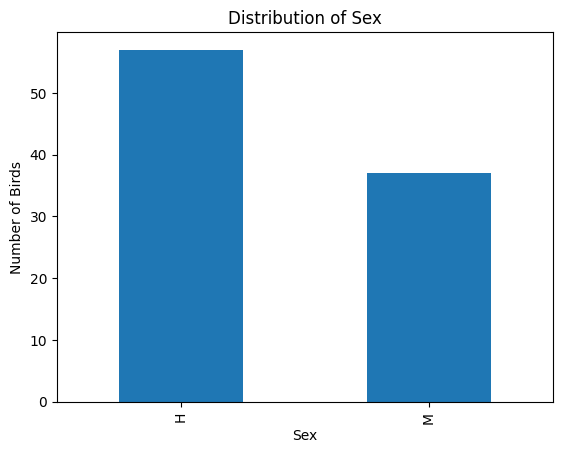

In [9]:
# Visualize Target Variable
train["sexo"].value_counts().plot(kind="bar")


plt.xlabel("Sex")
plt.ylabel("Number of Birds")
plt.title("Distribution of Sex")
plt.show()

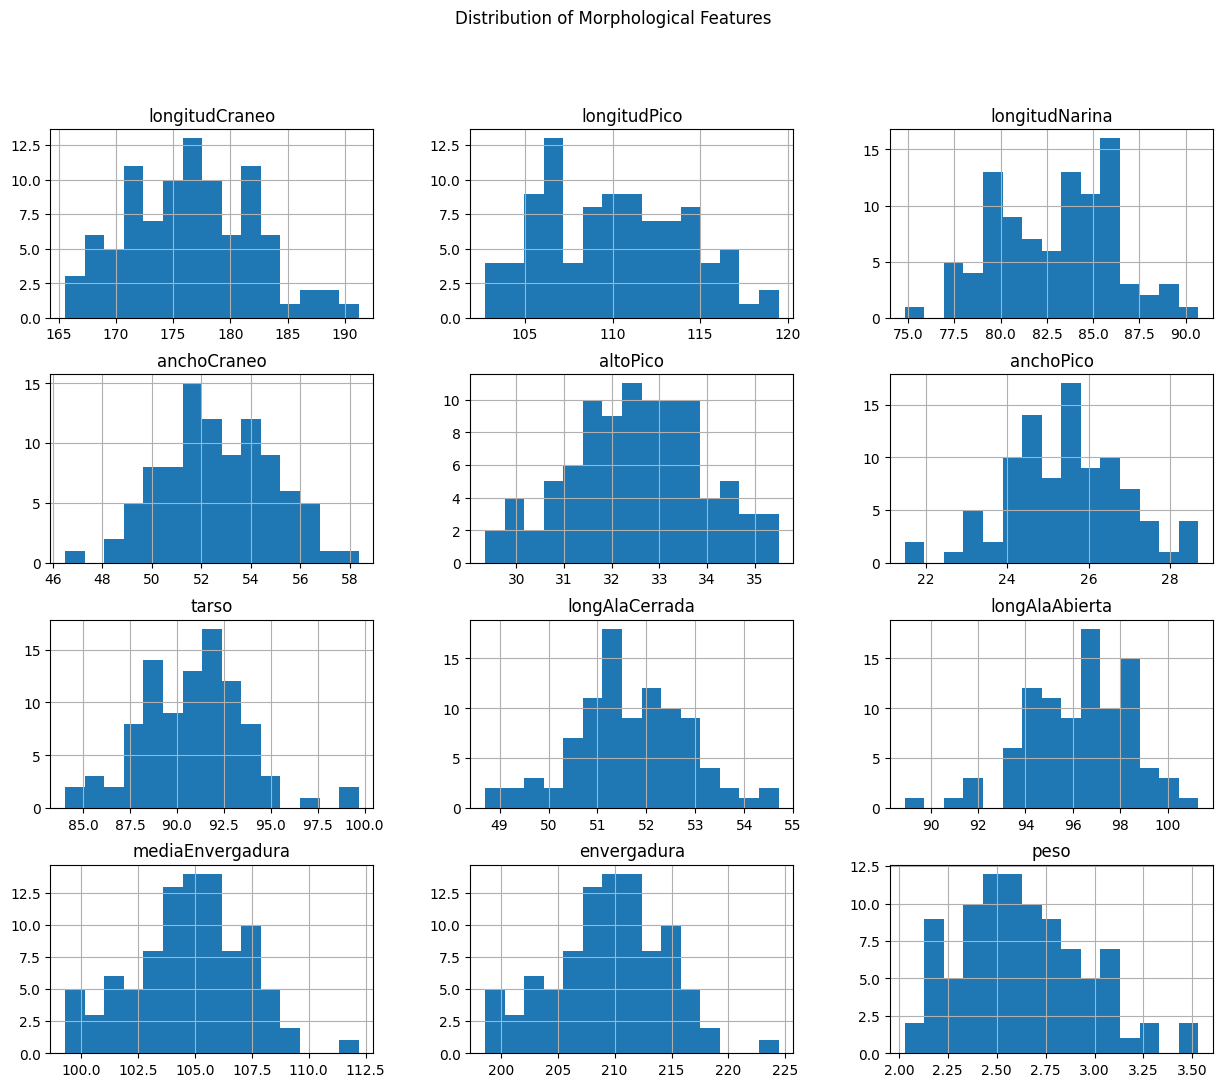

In [10]:
#EDA

import matplotlib.pyplot as plt

features = train.select_dtypes(include=np.number).columns

train[features].hist(figsize=(15, 12), bins=15)

plt.suptitle("Distribution of Morphological Features")
plt.show()

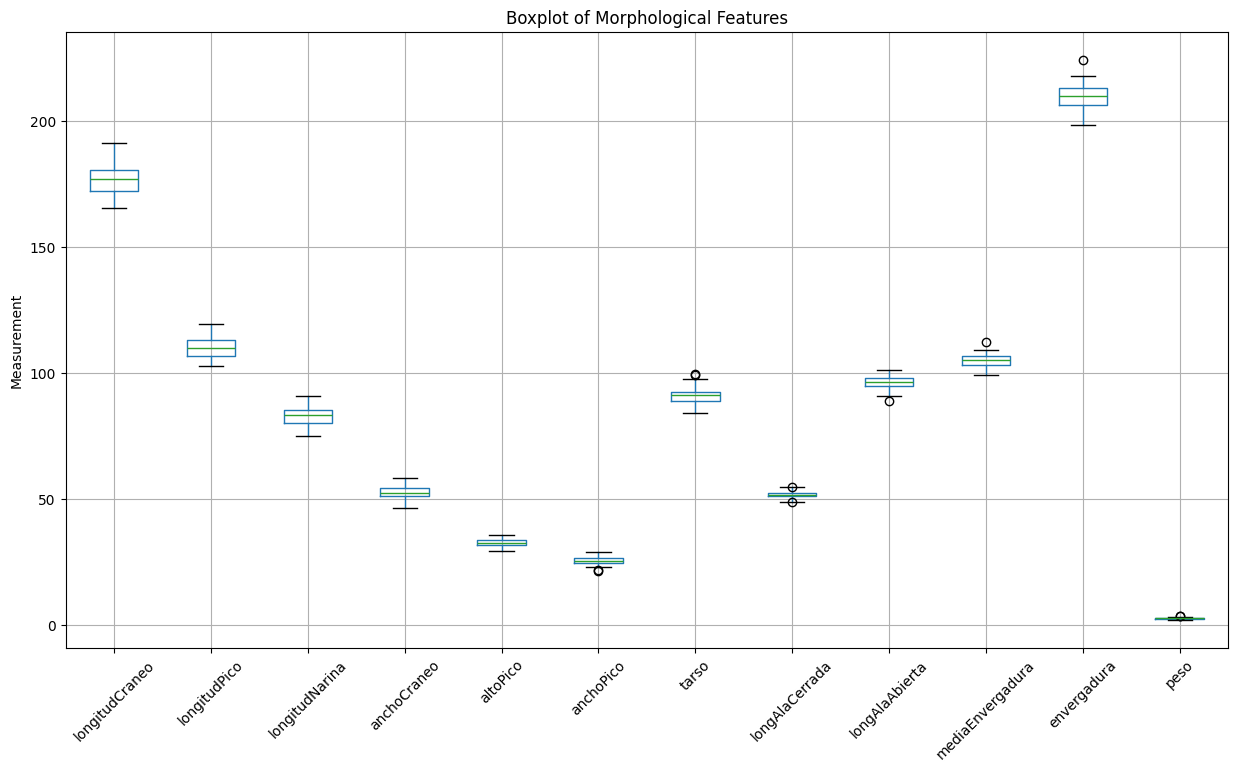

In [12]:
#Boxplot – Outlier Detection

plt.figure(figsize=(15, 8))

train[features].boxplot()

plt.title("Boxplot of Morphological Features")
plt.xticks(rotation=45)
plt.ylabel("Measurement")
plt.show()

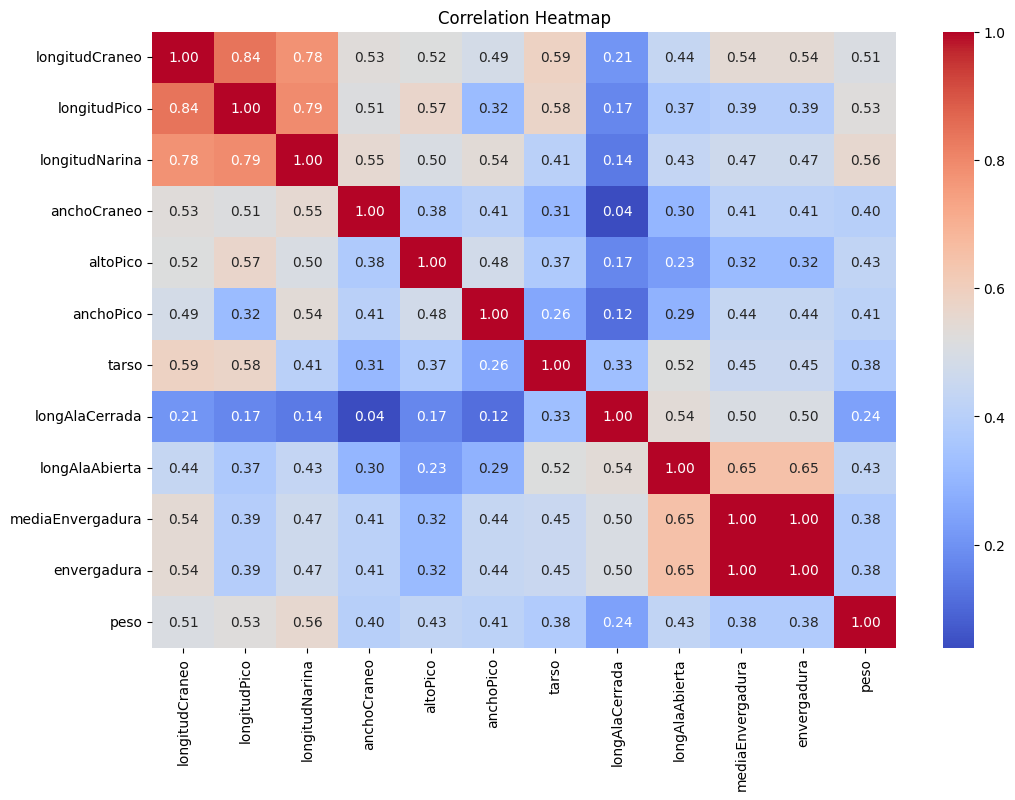

In [13]:
 #Correlation Heatmap


import seaborn as sns

plt.figure(figsize=(12, 8))

correlation = train[features].corr()
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()


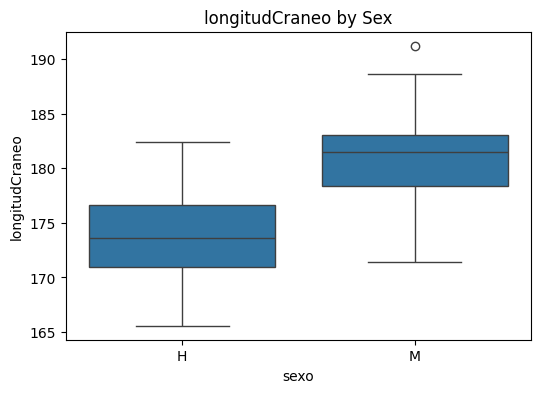

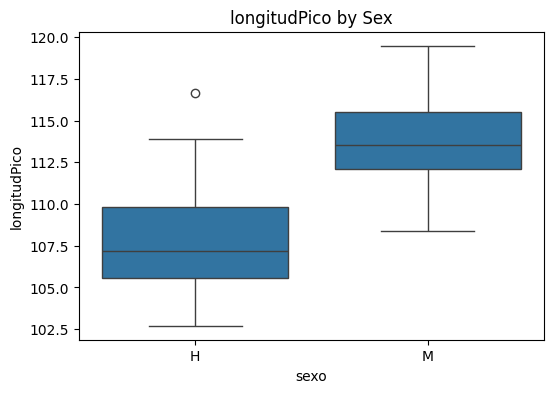

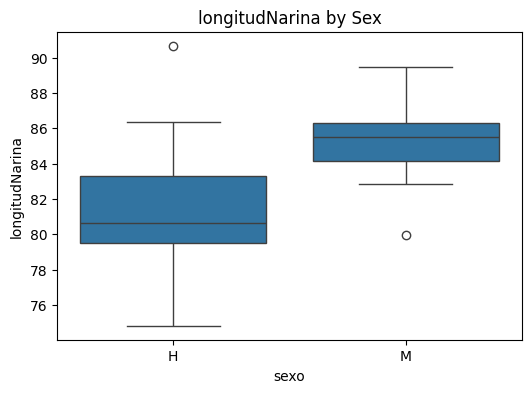

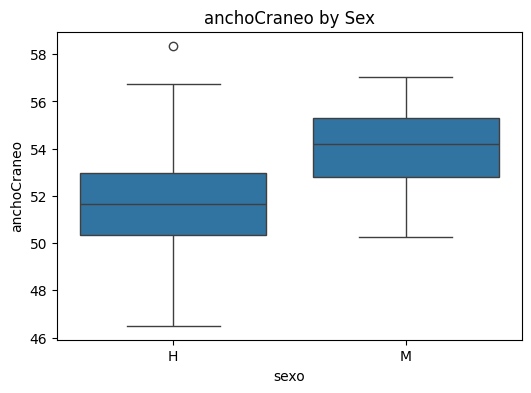

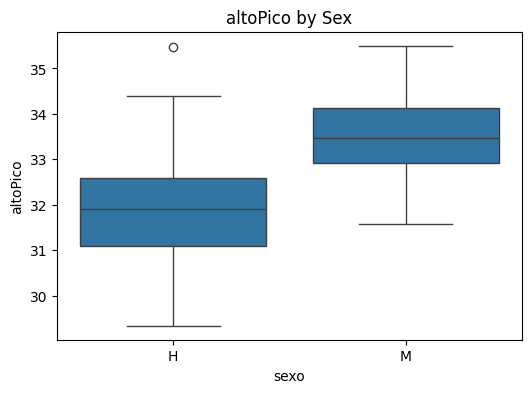

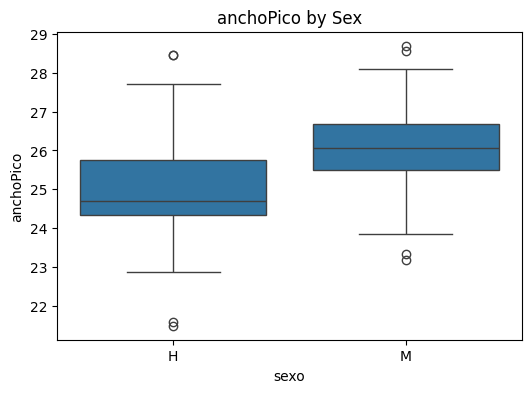

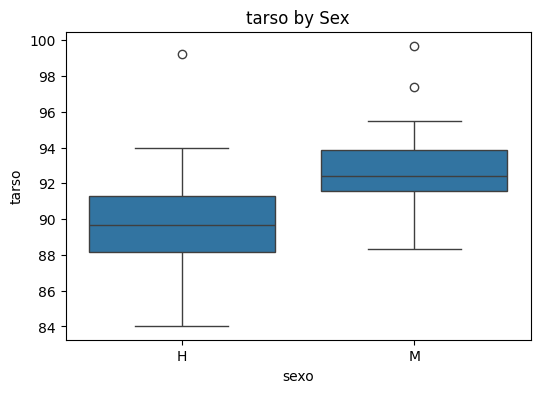

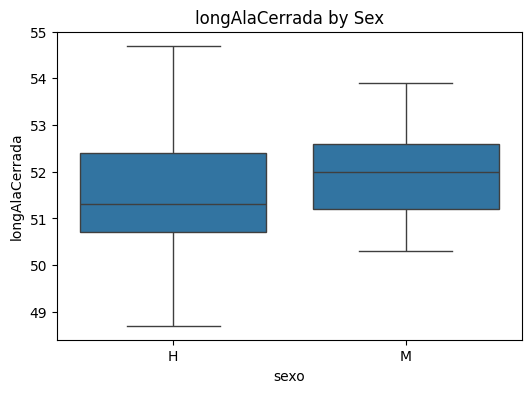

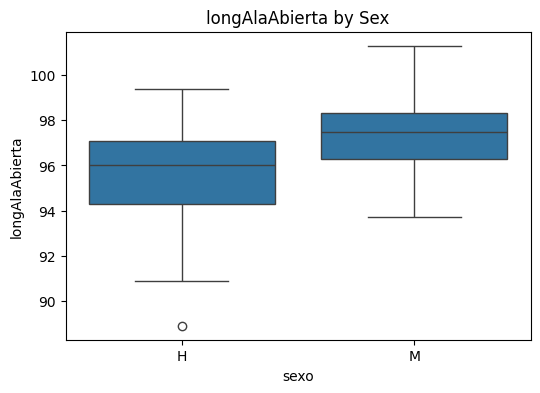

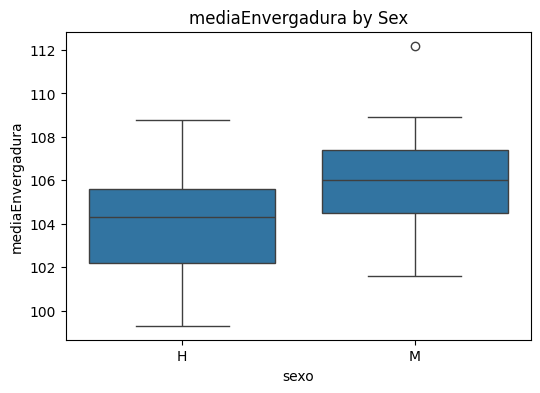

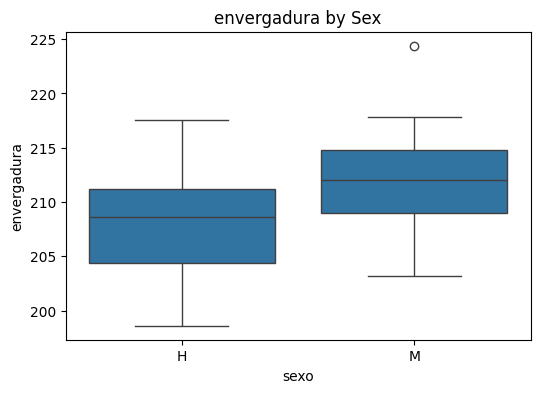

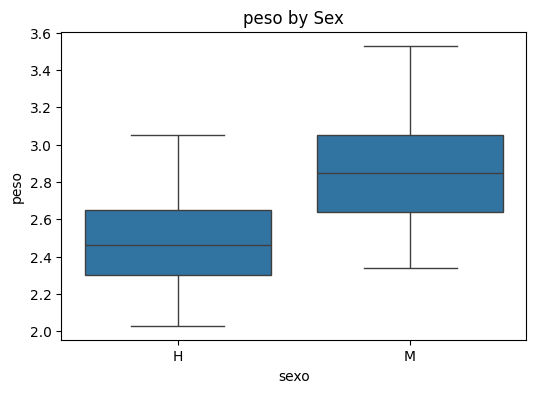

In [14]:
#Compare Measurements by Sex


for column in features:
    plt.figure(figsize=(6, 4))

    sns.boxplot(
        x="sexo",
        y=column,
        data=train
    )

    plt.title(f"{column} by Sex")
    plt.show()

In [16]:
#Data Preprocessing

X = train.drop(columns=["id", "sexo"])
y = train["sexo"]

X_test = test.drop(columns=["id"])

print("Features:")
print(X.columns)

Features:
Index(['longitudCraneo', 'longitudPico', 'longitudNarina', 'anchoCraneo',
       'altoPico', 'anchoPico', 'tarso', 'longAlaCerrada', 'longAlaAbierta',
       'mediaEnvergadura', 'envergadura', 'peso'],
      dtype='object')


In [17]:
#Handle Missing Values

imputer = SimpleImputer(strategy="median")

X = imputer.fit_transform(X)
X_test = imputer.transform(X_test)

print("Missing values handled successfully.")

Missing values handled successfully.


In [18]:
#Split Training Data

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Validation data:", X_val.shape)


Training data: (75, 12)
Validation data: (19, 12)


In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Feature scaling completed.")




Feature scaling completed.


In [21]:

model = LogisticRegression(
    C=0.1,
    max_iter=5000,
    random_state=42
)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [23]:
y_pred = model.predict(X_val)

print("Predicted values:")
print(y_pred)





Predicted values:
['M' 'H' 'M' 'H' 'H' 'H' 'H' 'H' 'M' 'H' 'H' 'H' 'H' 'M' 'M' 'H' 'M' 'H'
 'H']


In [24]:
accuracy = accuracy_score(y_val, y_pred)

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.8421052631578947


In [25]:
print(classification_report(y_val, y_pred))


              precision    recall  f1-score   support

           H       0.85      0.92      0.88        12
           M       0.83      0.71      0.77         7

    accuracy                           0.84        19
   macro avg       0.84      0.82      0.82        19
weighted avg       0.84      0.84      0.84        19



In [27]:
cm = confusion_matrix(y_val, y_pred)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[11  1]
 [ 2  5]]


In [28]:
final_model = LogisticRegression(
    C=0.1,
    max_iter=5000,
    random_state=42
)

final_model.fit(X_train, y_train)

print("Final model trained successfully.")

Final model trained successfully.


In [29]:
test_predictions = final_model.predict(X_test)

print("Test Predictions:")
print(test_predictions)

Test Predictions:
['M' 'H' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'H' 'H' 'H' 'M' 'H' 'H' 'H' 'H'
 'H' 'H' 'H' 'H' 'H' 'M' 'M' 'H' 'H' 'M' 'M' 'M' 'M' 'M' 'H' 'M' 'H' 'H'
 'H' 'H' 'M' 'M' 'M']


In [30]:
submission = pd.DataFrame({
    "id": test["id"],
    "sexo": test_predictions
})

submission.to_csv(
    "laysan_albatross_submission.csv",
    index=False
)

print("Submission file created successfully!")
print(submission.head())


Submission file created successfully!
         id sexo
0  A70_2018    M
1  5C9_2018    H
2  5E1_2018    M
3  C58_2018    M
4  5E2_2018    M


In [31]:
print("Submission Shape:", submission.shape)

print("\nColumns:")
print(submission.columns)

print("\nUnique Predictions:")
print(submission["sexo"].unique())

print("\nPrediction Count:")
print(submission["sexo"].value_counts())

Submission Shape: (41, 2)

Columns:
Index(['id', 'sexo'], dtype='object')

Unique Predictions:
['M' 'H']

Prediction Count:
sexo
M    21
H    20
Name: count, dtype: int64


In [32]:
print(submission)


          id sexo
0   A70_2018    M
1   5C9_2018    H
2   5E1_2018    M
3   C58_2018    M
4   5E2_2018    M
5   5C2_2018    M
6   E21_2018    M
7   1C2_2018    M
8   C90_2018    M
9   A87_2018    M
10  2H7_2018    H
11  C99_2018    H
12  6C2_2017    H
13  E21_2017    M
14  6C1_2016    H
15  6E0_2016    H
16  2A2_2016    H
17  J46_2016    H
18  H67_2016    H
19  E93_2016    H
20  A67_2016    H
21  H19_2016    H
22  B68_2016    H
23  E04_2016    M
24  C91_2016    M
25  8C3_2016    H
26  J45_2016    H
27  7E9_2016    M
28  1E3_2016    M
29  0J5_2016    M
30  H23_2016    M
31  E11_2016    M
32  4A5_2016    H
33  K89_2016    M
34  3A2_2015    H
35  2C3_2015    H
36  C43_2015    H
37  0C4_2015    H
38  A56_2015    M
39  9B6_2015    M
40  H72_2015    M
